In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import math

In [40]:
def compute_autocorrelation(data):
    tmax = len(data)
    autocorr = np.empty(tmax)
    
    avg_tot_2 = np.sum(data * data) / tmax
    avg_tot = np.sum(data) / tmax
    var_tot = avg_tot_2 - np.power(avg_tot, 2)
    
    for t in range(tmax):
        dt = tmax - t
        num = np.sum(data[:dt]*data[t:])/dt - np.sum(data)*np.sum(data[t:])/(dt*dt)
        autocorr[t] = num / var_tot
    
    return autocorr
        
        

In [ ]:
steps, energy = np.loadtxt("../OUTPUT-2/potential_energy.dat", usecols=(0,1), unpack=True)

autocorrelation = compute_autocorrelation(energy)

In [37]:
plt.plot(steps, autocorrelation)


[ 1  4 16 25]


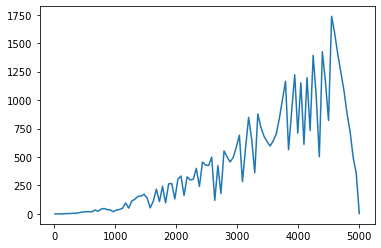

In [36]:
L = np.linspace(10,5000, 100)

def error(L, data):
    N = int(len(data)//L)
    averages = np.zeros(N)
    for i in range(N):
        averages[i] = np.sum(data[i*L:(i+1)*L])
    sum_averages = np.sum(data) / N
    sum_averages2 = np.sum(averages * averages) / N
    return math.sqrt(abs((sum_averages2-np.power(sum_averages,2)))/(N-1))

errors = [error(int(l), energy) for l in L]

plt.plot(L, errors);